In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.config import INTERIM_DATA_DIR

from src.config import INTERIM_DATA_DIR

from src.visualization import (
    load_cleaned_dataset,
    get_dataset_overview,
    get_target_distribution,
    plot_target_distribution,
    get_numerical_summary,
    plot_numerical_distributions,
    plot_boxplots,
    plot_correlation_heatmap,
    get_categorical_summary,
    plot_categorical_distributions,
    plot_feature_vs_target,
    detect_outliers_iqr
)

In [3]:
eda_df = load_cleaned_dataset(
    INTERIM_DATA_DIR / "cleaned_data.csv"
)

In [4]:
overview = get_dataset_overview(eda_df)

overview

{'Rows': 32416,
 'Columns': 12,
 'Numerical Columns': 8,
 'Categorical Columns': 4,
 'Memory Usage (MB)': 8.58}

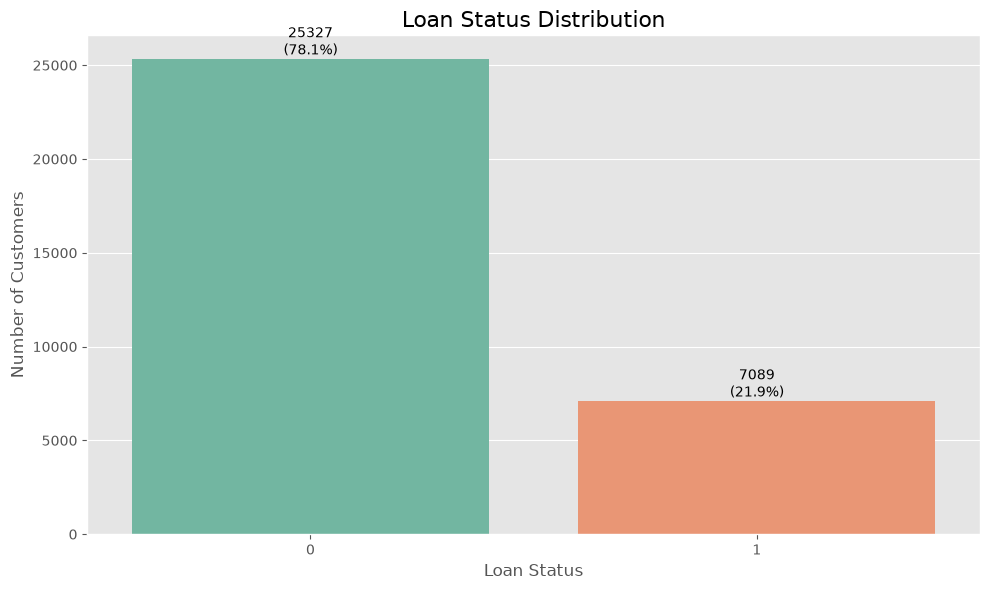

In [5]:
import matplotlib.pyplot as plt
plot_target_distribution(
    eda_df,
    "loan_status"
)

plt.show()

## Target Variable Summary

In [6]:
target_summary = get_target_distribution(
    eda_df,
    "loan_status"
)

display(target_summary)

,Count,Percentage
loan_status,,
0,25327,78.13
1,7089,21.87


<Axes: title={'center': 'Loan Status Distribution'}, xlabel='Loan Status', ylabel='Number of Customers'>

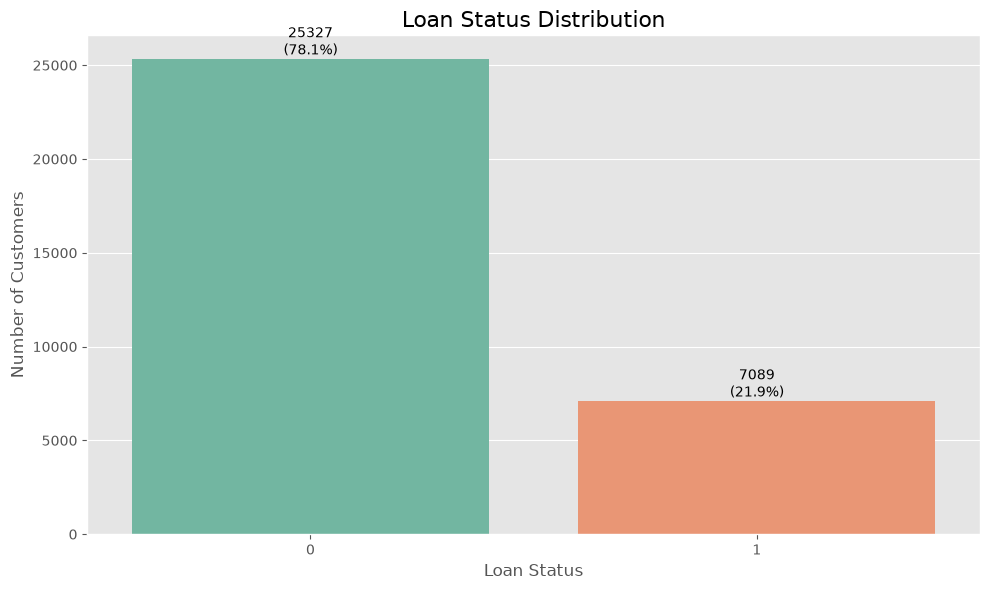

In [7]:
plot_target_distribution(
    eda_df,
    "loan_status"
)

### Interpretation

- The dataset contains 32,416 loan records after preprocessing.
- Approximately 78.13% of the loans belong to the non-default class (loan_status = 0).
- Around 21.87% of the loans belong to the default class (loan_status = 1).
- The dataset exhibits a moderate class imbalance, with the majority class significantly larger than the minority class.
- During model training, techniques such as class weighting or oversampling (e.g., SMOTE) may be considered if the imbalance negatively affects model performance.

In [8]:
numerical_summary = get_numerical_summary(
    eda_df
)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max,Skewness
person_age,32416.0,27.75,6.35,20.00,23.00,26.00,30.00,144.00,2.58
person_income,32416.0,66091.64,62015.58,4000.00,38542.00,55000.00,79218.00,6000000.00,32.96
person_emp_length,32416.0,4.77,4.09,0.00,2.00,4.00,7.00,123.00,2.67
loan_amnt,32416.0,9593.85,6322.73,500.00,5000.00,8000.00,12250.00,35000.00,1.19
loan_int_rate,32416.0,11.01,3.08,5.42,8.49,10.99,13.11,23.22,0.22
loan_status,32416.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00,1.36
loan_percent_income,32416.0,0.17,0.11,0.00,0.09,0.15,0.23,0.83,1.06
cb_person_cred_hist_length,32416.0,5.81,4.06,2.00,3.00,4.00,8.00,30.00,1.66


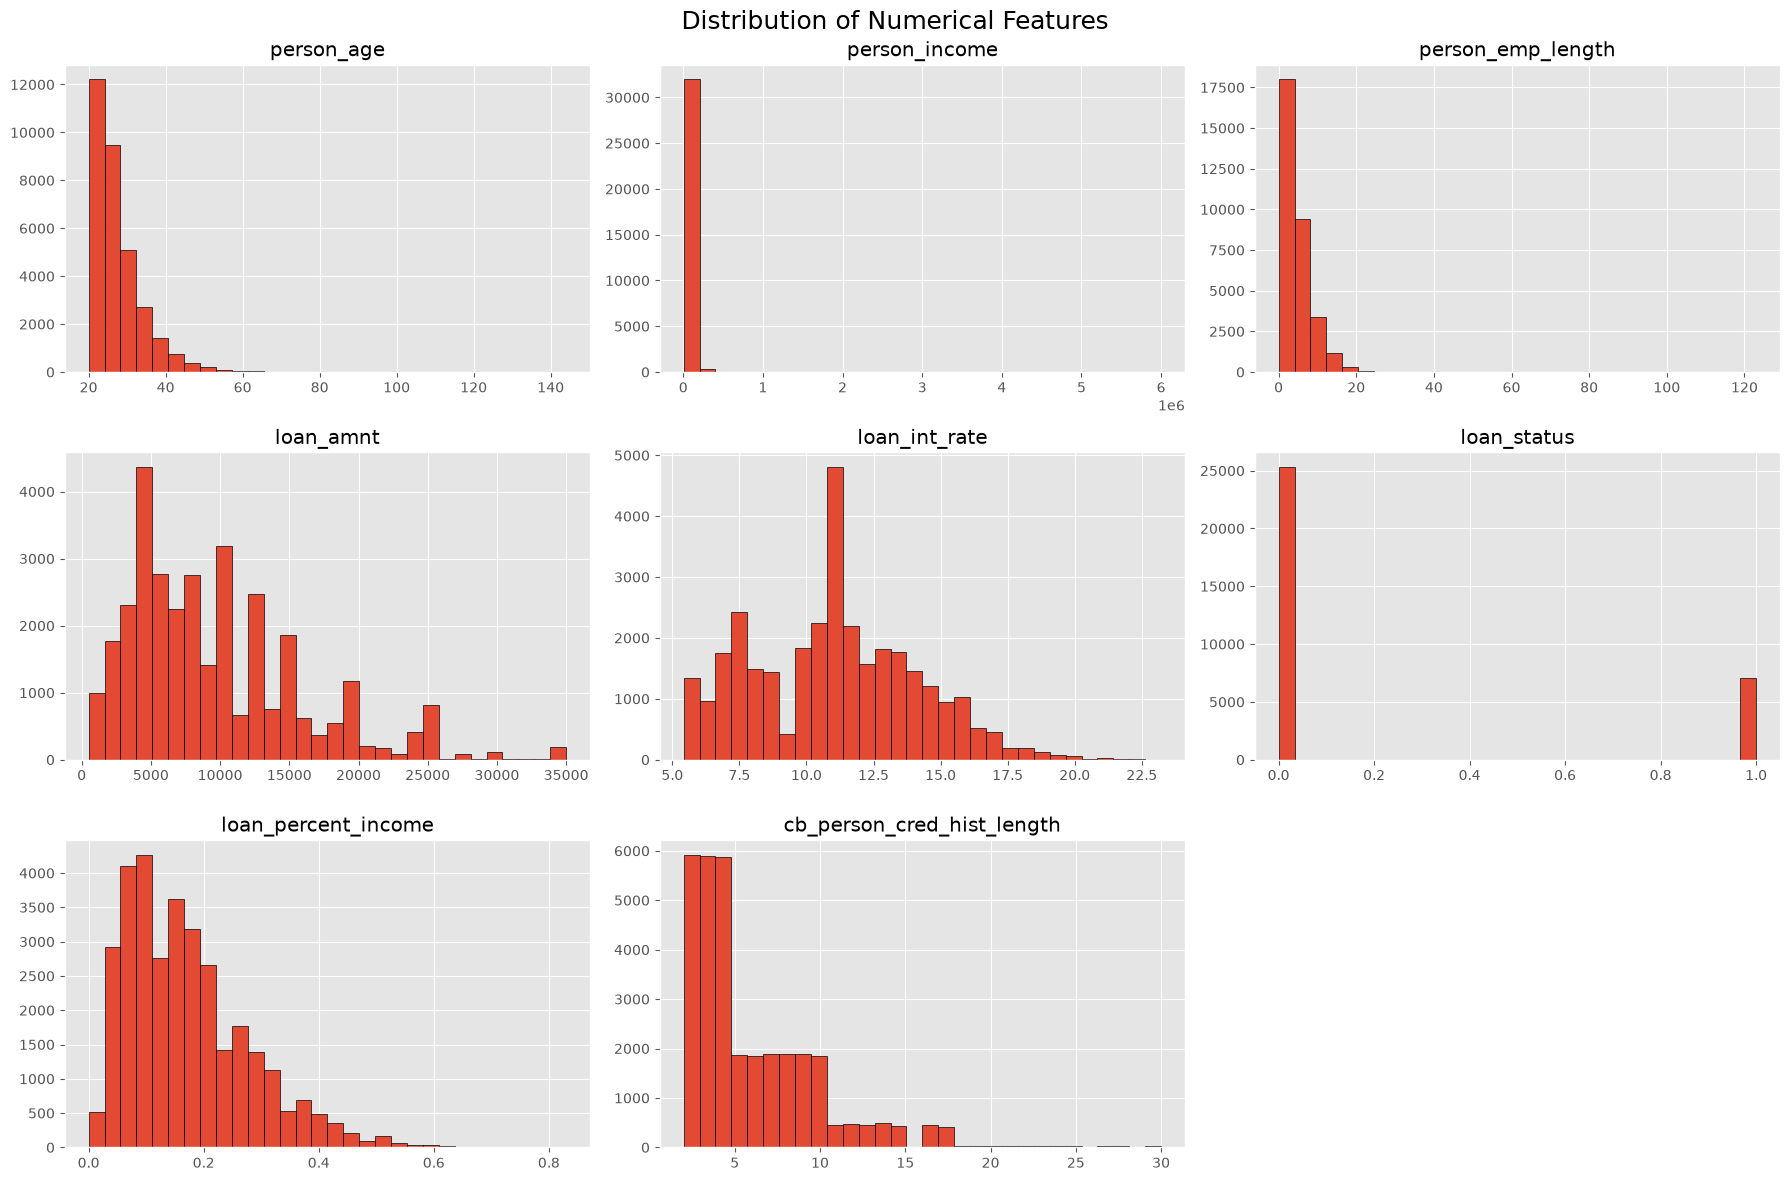

In [9]:
plot_numerical_distributions(
    eda_df
)

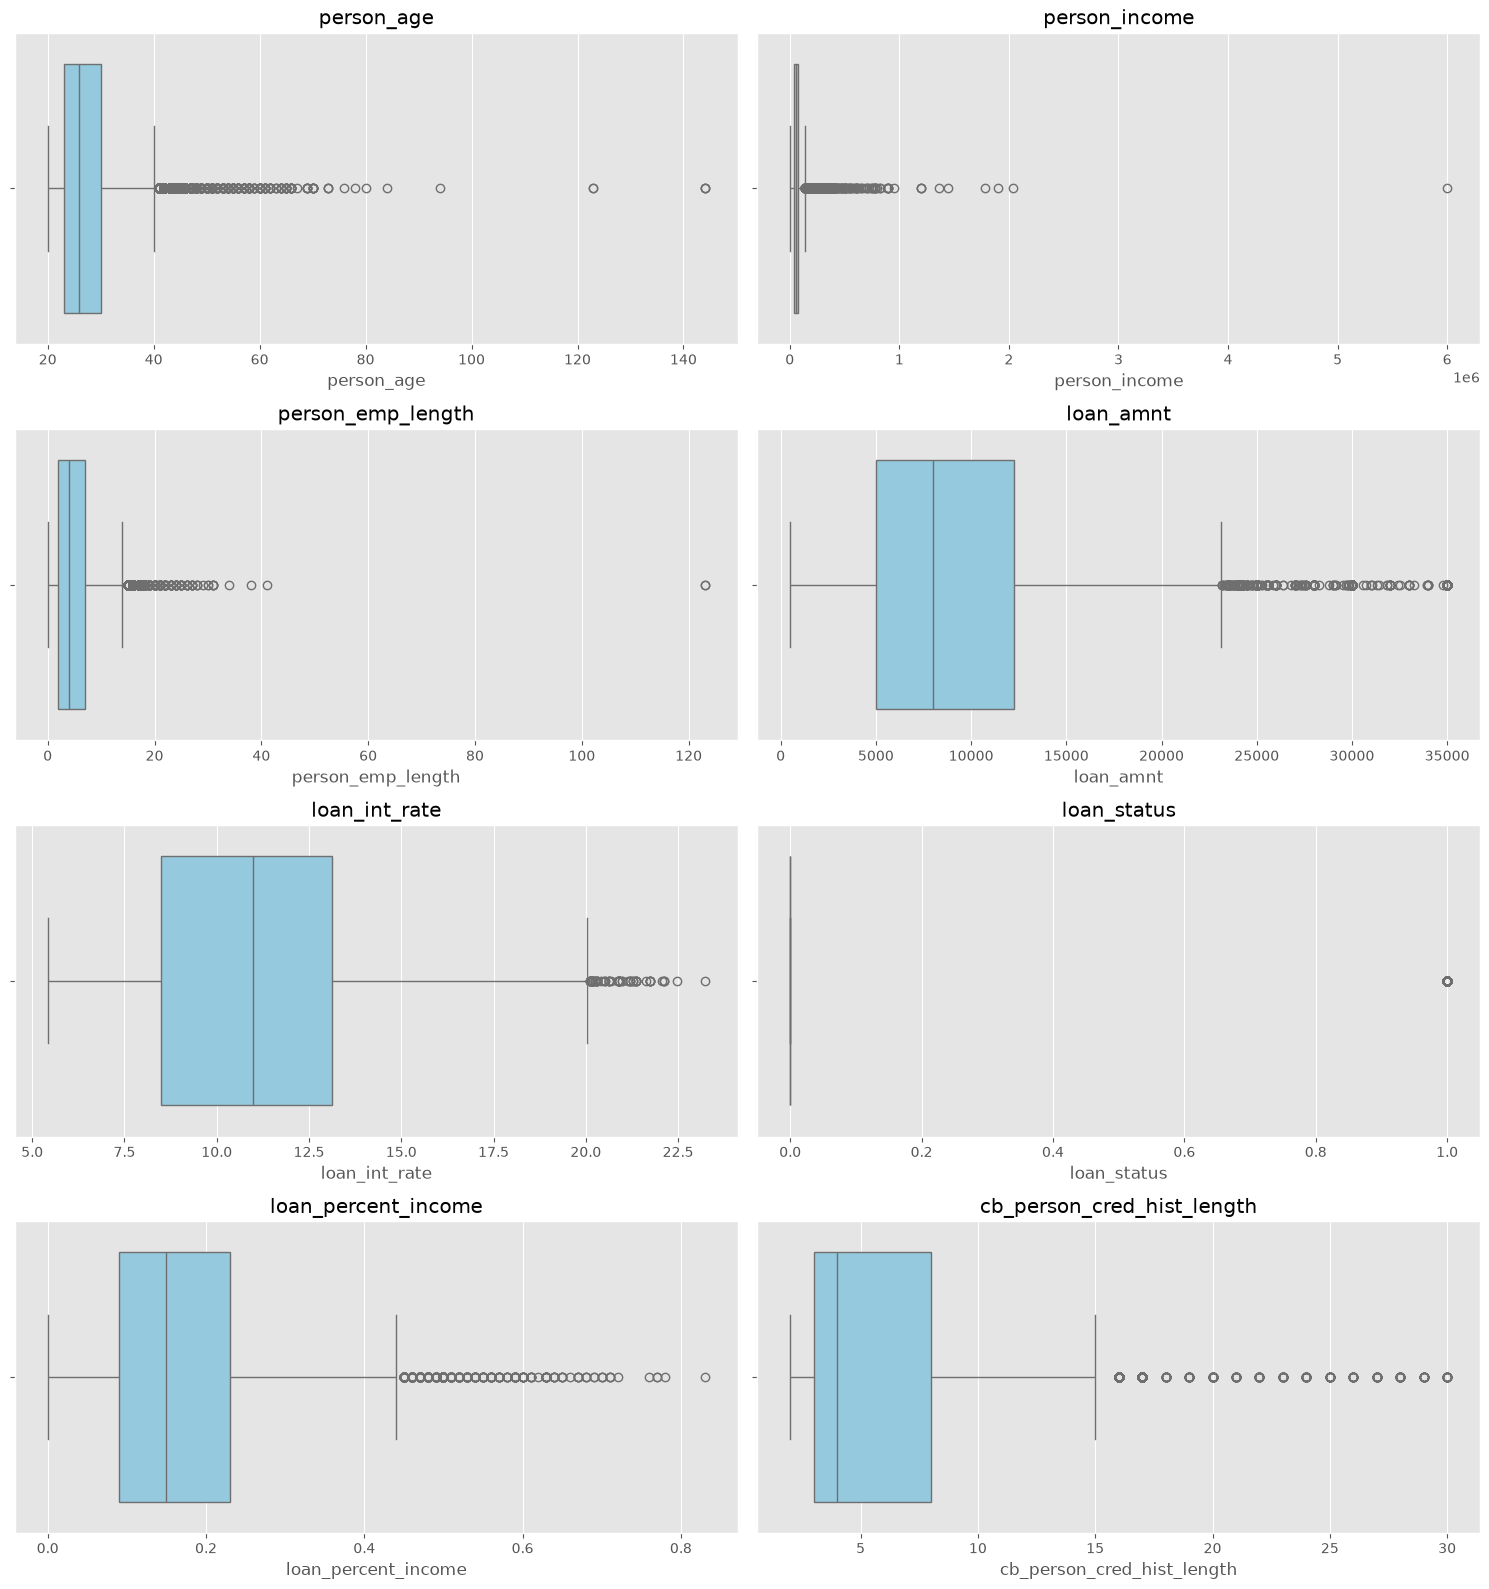

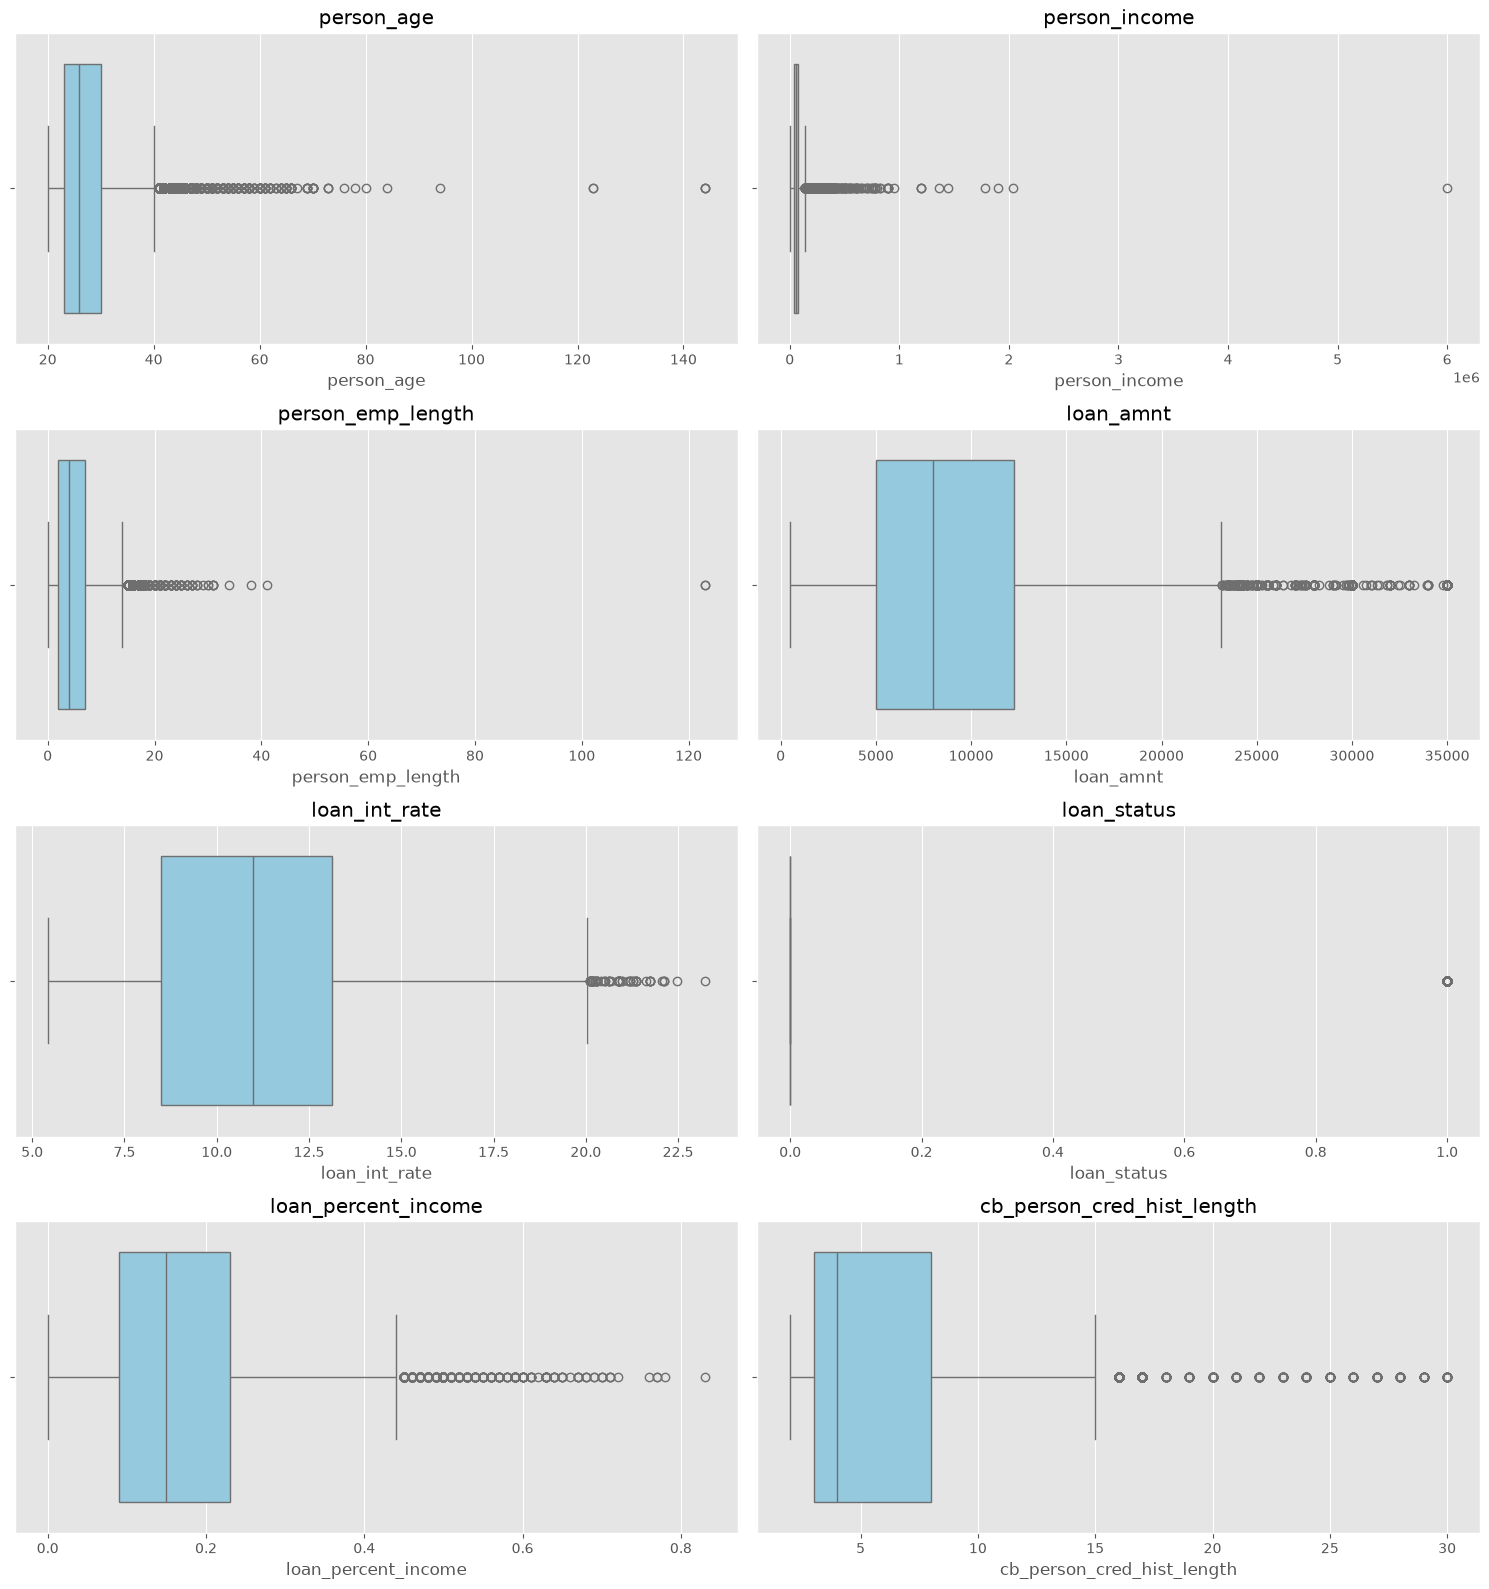

In [10]:
plot_boxplots(
    eda_df
)

<Axes: title={'center': 'Correlation Heatmap'}>

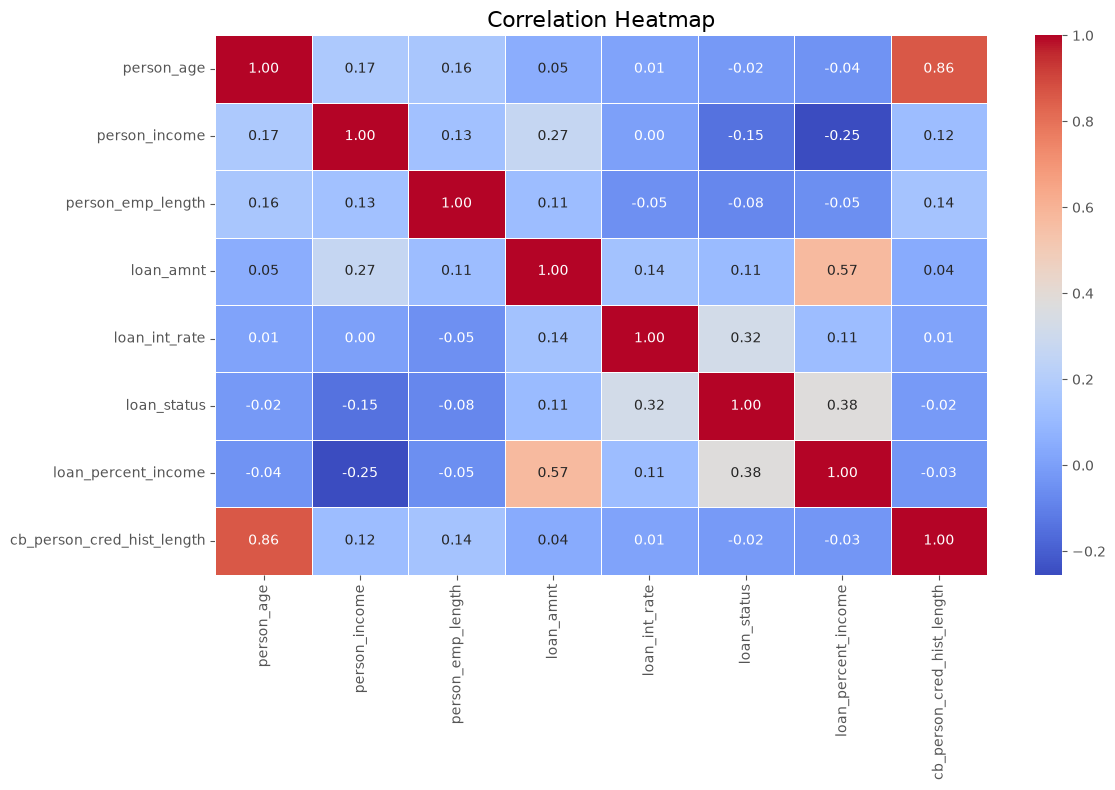

In [11]:
plot_correlation_heatmap(
    eda_df
)

In [12]:
categorical_summary = get_categorical_summary(
    eda_df
)

for column, summary in categorical_summary.items():
    print(f"\n{column}")
    display(summary)


person_home_ownership


person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64


loan_intent


loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64


loan_grade


loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64


cb_person_default_on_file


cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64

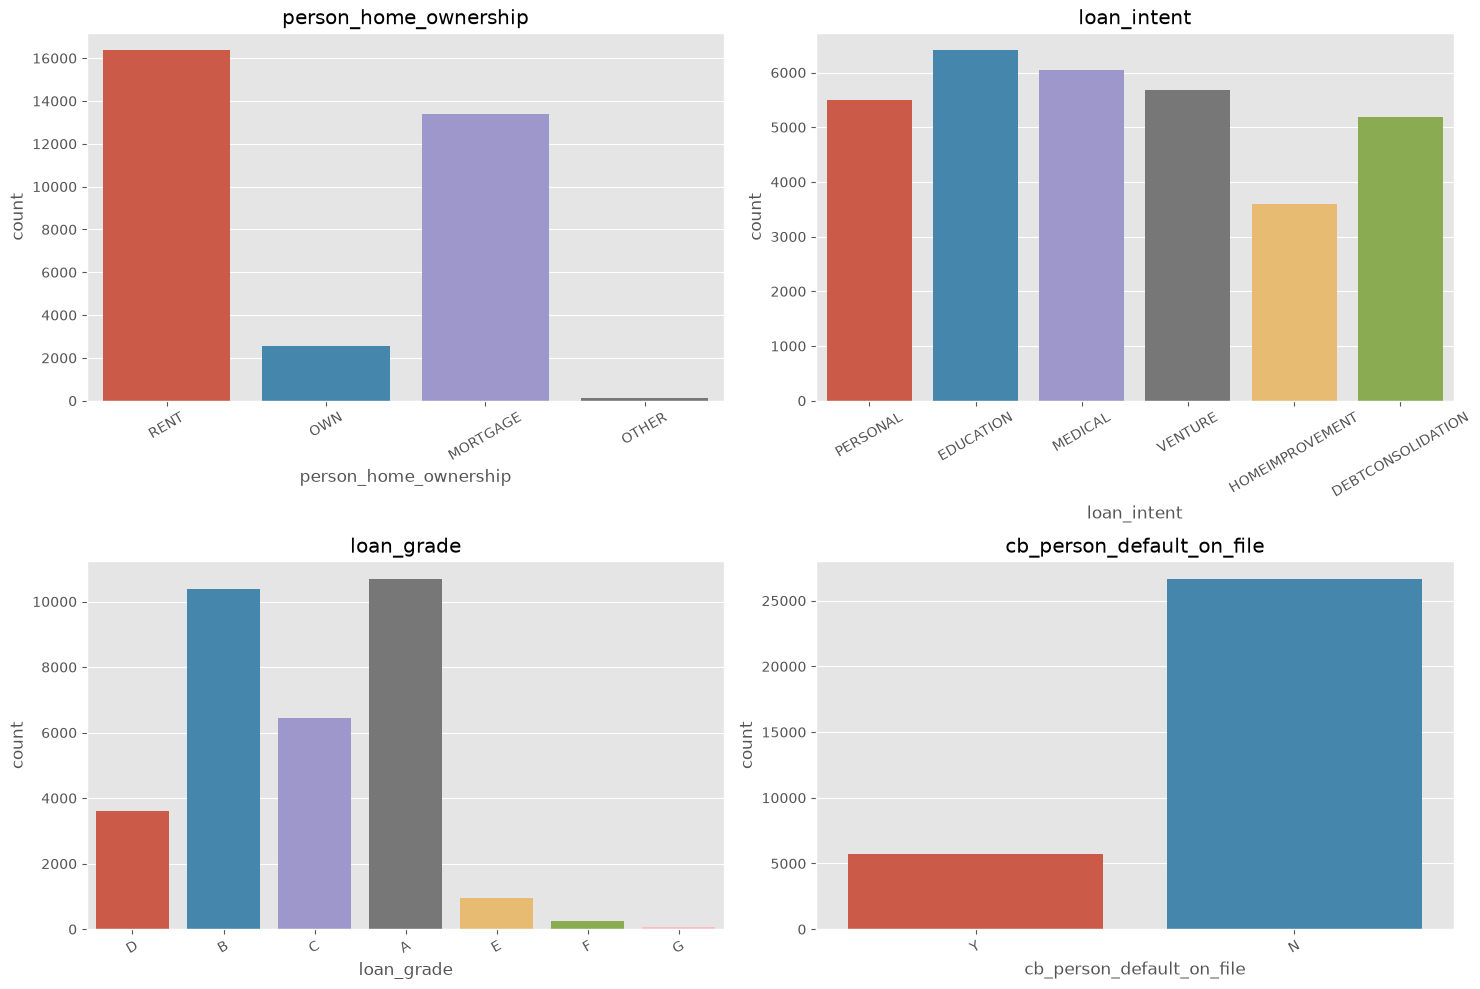

In [13]:
plot_categorical_distributions(
    eda_df
)

<Axes: title={'center': 'person_income vs loan_status'}, xlabel='loan_status', ylabel='person_income'>

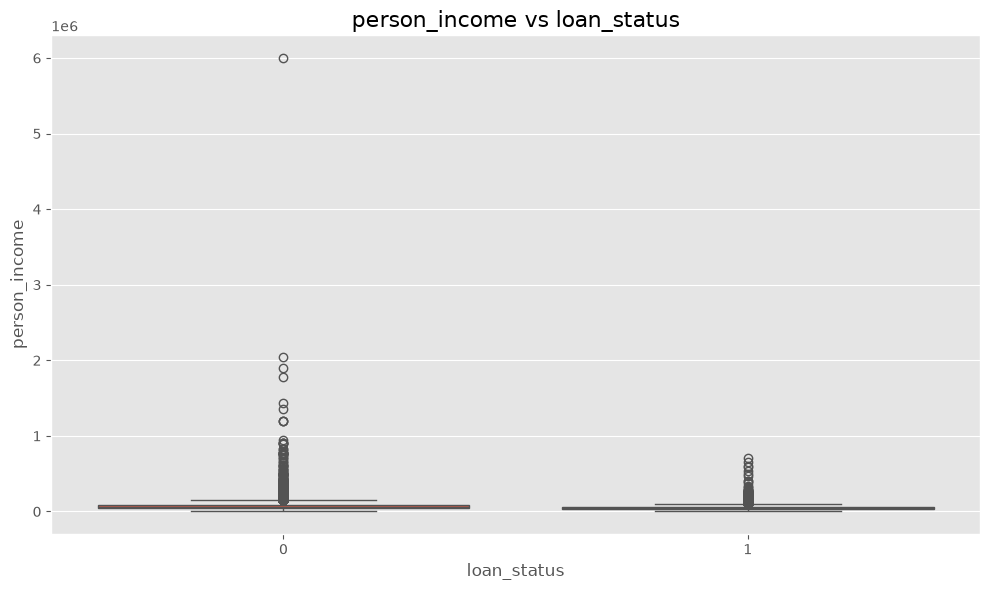

In [14]:
plot_feature_vs_target(
    eda_df,
    "person_income",
    "loan_status"
)

<Axes: title={'center': 'loan_amnt vs loan_status'}, xlabel='loan_status', ylabel='loan_amnt'>

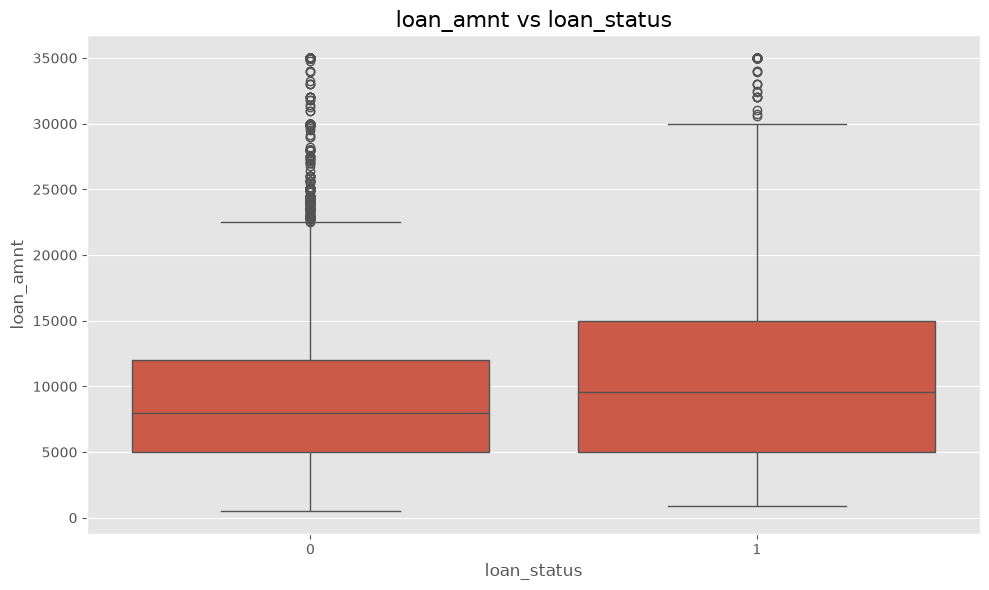

In [15]:
plot_feature_vs_target(
    eda_df,
    "loan_amnt",
    "loan_status"
)

<Axes: title={'center': 'loan_int_rate vs loan_status'}, xlabel='loan_status', ylabel='loan_int_rate'>

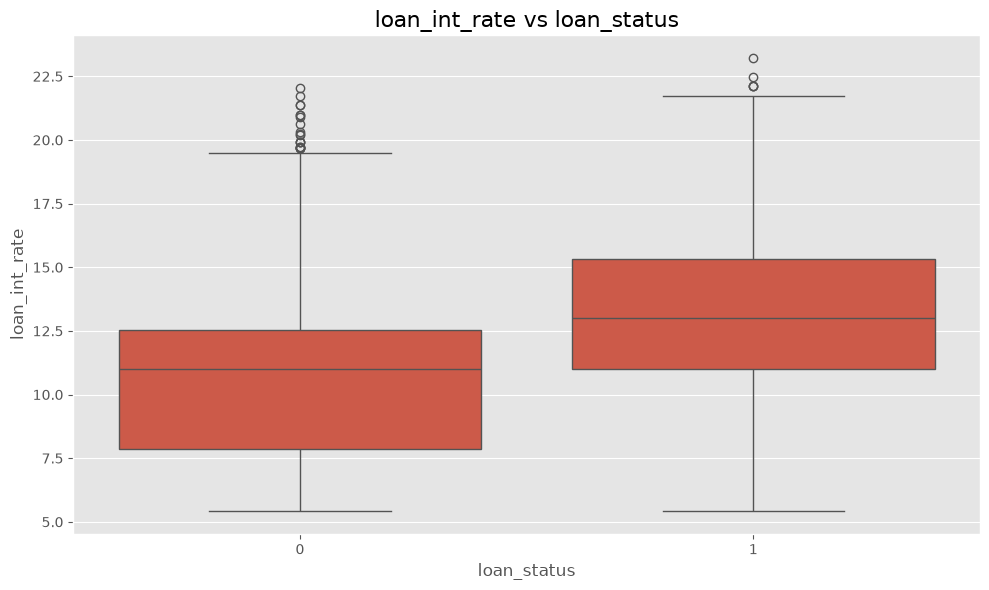

In [16]:
plot_feature_vs_target(
    eda_df,
    "loan_int_rate",
    "loan_status"
)

<Axes: title={'center': 'loan_percent_income vs loan_status'}, xlabel='loan_status', ylabel='loan_percent_income'>

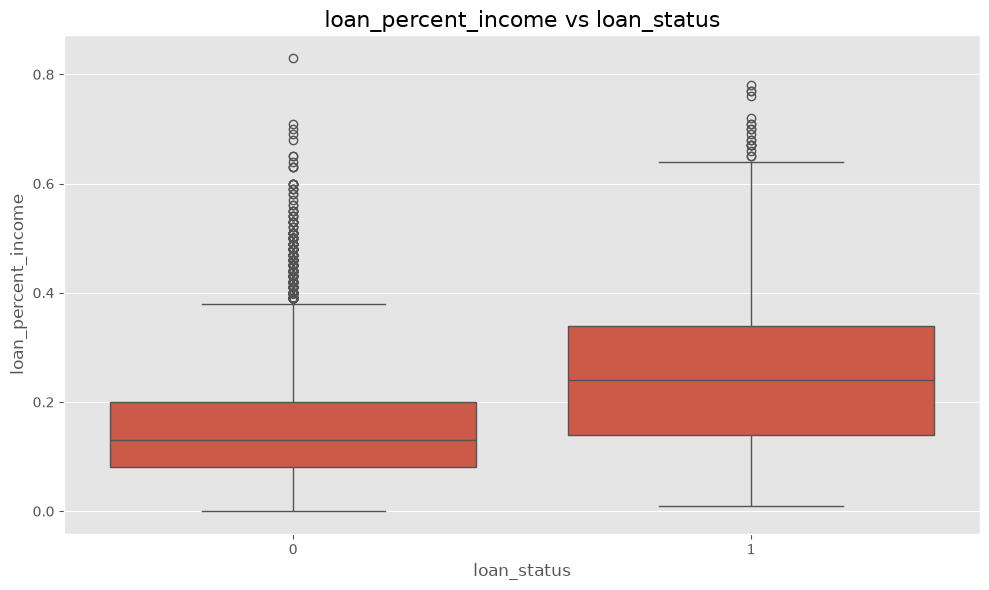

In [17]:
plot_feature_vs_target(
    eda_df,
    "loan_percent_income",
    "loan_status"
)

In [18]:
outlier_report = detect_outliers_iqr(
    eda_df
)

display(outlier_report)

,Feature,Outliers,Percentage
0,person_age,1491,4.60
1,person_income,1478,4.56
2,person_emp_length,852,2.63
3,loan_amnt,1679,5.18
4,loan_int_rate,70,0.22
5,loan_status,7089,21.87
6,loan_percent_income,650,2.01
7,cb_person_cred_hist_length,1139,3.51


# EDA Conclusions

## Key Findings

- The cleaned dataset contains 32,416 observations and 12 features.
- The target variable is moderately imbalanced, with approximately 78% non-default loans and 22% default loans.
- Numerical features exhibit varying distributions, with some showing noticeable skewness.
- Several numerical variables contain potential outliers identified through boxplots and IQR analysis.
- Correlation analysis highlights relationships among numerical variables that will be considered during feature engineering.
- Categorical features display distinct distributions and will require appropriate encoding before model training.
- The insights obtained during EDA will guide feature engineering, preprocessing, and machine learning model development.

# EDA Conclusions

## Dataset Summary
- The cleaned dataset contains 32,416 records and 12 features.
- Both numerical and categorical features are present.

## Target Variable
- The target variable (`loan_status`) is moderately imbalanced.
- Approximately 78% of observations belong to the non-default class, while around 22% belong to the default class.

## Numerical Features
- Several numerical variables exhibit skewed distributions.
- Boxplots indicate the presence of potential outliers in multiple features.
- Summary statistics and histograms provide insights into the spread and central tendency of the data.

## Categorical Features
- Categorical variables contain distinct categories with varying frequencies.
- These features will require encoding during feature engineering.

## Correlation Analysis
- Correlation analysis identifies relationships among numerical variables.
- These relationships will be considered during feature selection and model development.

## Outlier Analysis
- The IQR method identifies potential outliers in several numerical features.
- Decisions regarding outlier treatment will be taken during feature engineering.

## Next Step
The insights obtained from this exploratory data analysis will guide feature engineering, data transformation, feature encoding, and machine learning model development.